In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import requests
import io
from sklearn.model_selection import train_test_split

In [2]:
# historical_url = 'https://en.wikipedia.org/w/index.php?title=NIFTY_50&oldid=1217916746#Constituents' # 28 March 2024
historical_url = 'https://en.wikipedia.org/w/index.php?title=NIFTY_50&oldid=1284465884#Constituents' # 28 March 2025

tables = pd.read_html(
    historical_url,
    match='Symbol', 
    storage_options={'User-Agent': 'Mozilla/5.0'}
)

nifty50_df = tables[0]
tickers = nifty50_df['Symbol'].astype(str) + '.NS'

print("Historical Constituents List:")
print(tickers.tolist())

Historical Constituents List:
['ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BEL.NS', 'BHARTIARTL.NS', 'CIPLA.NS', 'COALINDIA.NS', 'DRREDDY.NS', 'EICHERMOT.NS', 'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS', 'HEROMOTOCO.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INDUSINDBK.NS', 'INFY.NS', 'ITC.NS', 'JIOFIN.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LT.NS', 'M&M.NS', 'MARUTI.NS', 'NESTLEIND.NS', 'NTPC.NS', 'ONGC.NS', 'POWERGRID.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SHRIRAMFIN.NS', 'SBIN.NS', 'SUNPHARMA.NS', 'TCS.NS', 'TATACONSUM.NS', 'TATAMOTORS.NS', 'TATASTEEL.NS', 'TECHM.NS', 'TITAN.NS', 'TRENT.NS', 'ULTRACEMCO.NS', 'WIPRO.NS', 'ZOMATO.NS']


In [3]:
tickers = nifty50_df['Symbol'].astype('str') + '.NS'
tickers_list = tickers.to_list()

# 2 years:
# raw_train_data = yf.download(tickers_list, start='2020-04-01', end='2024-03-31', interval='1d')
# raw_test_data = yf.download(tickers_list, start='2024-04-01', interval='1d')

# 1 year:
raw_train_data = yf.download(tickers_list, start='2021-04-01', end='2025-03-31', interval='1d')
raw_test_data = yf.download(tickers_list, start='2025-04-01', interval='1d')

/tmp/ipykernel_6569/3208562896.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_train_data = yf.download(tickers_list, start='2021-04-01', end='2025-03-31', interval='1d')
[**********************68%********               ]  34 of 50 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
[*********************100%***********************]  50 of 50 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['ZOMATO.NS', 'TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')
/tmp/ipykernel_6569/3208562896.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_test_data = yf.download(tickers_list, start='2025-04-01', interval='1d')
[*********************100%***********************]  50 of 50 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['ZOMATO.NS', 'TATAMOTORS.NS']: YFTzMi

In [4]:
# nifty50_index = yf.download('^NSEI', start='2024-04-01', interval='1d')
nifty50_index = yf.download('^NSEI', start='2025-04-01', interval='1d')

/tmp/ipykernel_6569/989106211.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty50_index = yf.download('^NSEI', start='2025-04-01', interval='1d')
[*********************100%***********************]  1 of 1 completed


In [5]:
close_train_prices = raw_train_data['Close']
close_test_prices = raw_test_data['Close']
benchmark = nifty50_index['Close']

In [6]:
display(close_train_prices.isna().sum())
display(close_test_prices.isna().sum())
display(benchmark.isna().sum())

,0
Ticker,
ADANIENT.NS,0
ADANIPORTS.NS,0
APOLLOHOSP.NS,0
ASIANPAINT.NS,0
AXISBANK.NS,0
BAJAJ-AUTO.NS,0
BAJAJFINSV.NS,0
BAJFINANCE.NS,0
BEL.NS,0


,0
Ticker,
ADANIENT.NS,0
ADANIPORTS.NS,0
APOLLOHOSP.NS,0
ASIANPAINT.NS,0
AXISBANK.NS,0
BAJAJ-AUTO.NS,0
BAJAJFINSV.NS,0
BAJFINANCE.NS,0
BEL.NS,0


,0
Ticker,
^NSEI,0


In [7]:
common_cols = close_train_prices.columns.intersection(close_test_prices.columns)

valid_cols = [
    c for c in common_cols
    if close_train_prices[c].notna().all() and close_test_prices[c].notna().all()
]

close_train_prices = close_train_prices.loc[:, valid_cols]
close_test_prices = close_test_prices.loc[:, valid_cols]

In [9]:
display(close_train_prices.columns.value_counts().sum())
display(close_test_prices.columns.value_counts().sum())

np.int64(47)

np.int64(47)

In [10]:
log_returns = np.log(close_train_prices/close_train_prices.shift(1)).dropna()

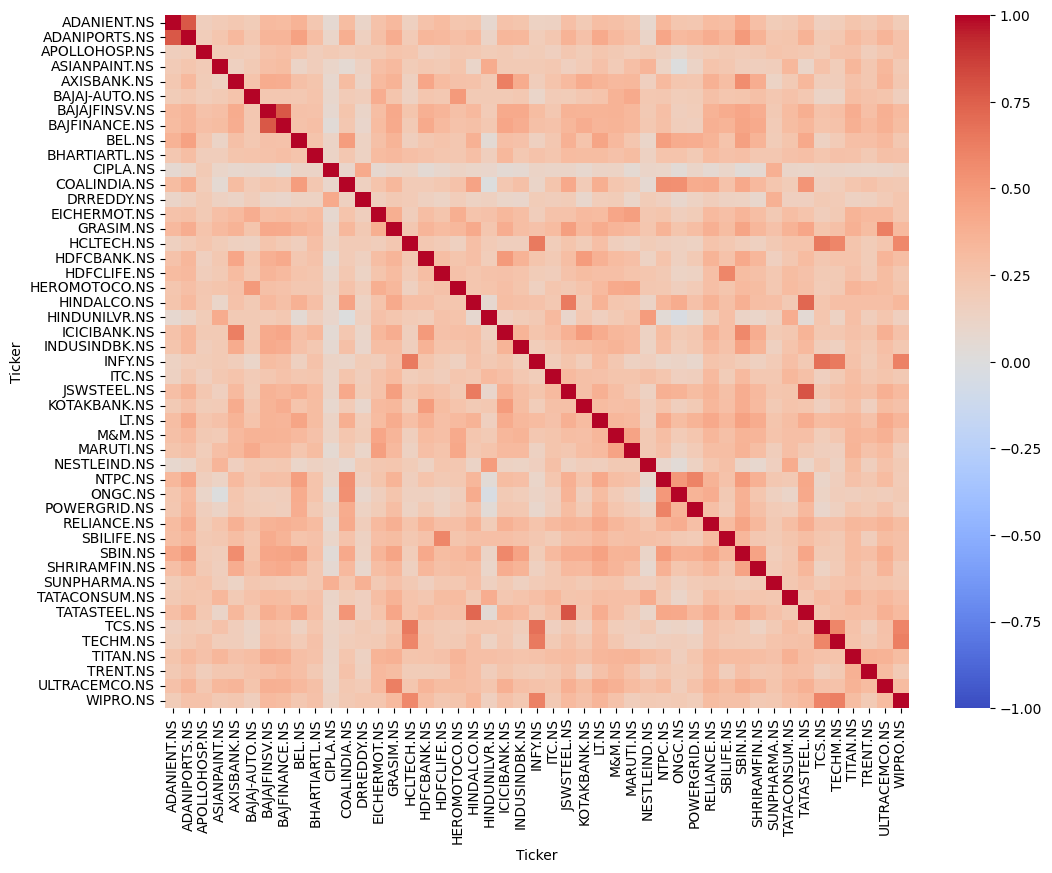

In [11]:
corr_matrix = log_returns.corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [12]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)

pca = PCA(n_components=10)
pca.fit(scaled_log_returns)

PCA(n_components=10)

In [13]:
display(pca.explained_variance_)
display(pca.explained_variance_ratio_)

array([13.41273909,  3.01735761,  2.4879929 ,  1.88500863,  1.35916117,
        1.35455869,  1.32570687,  1.19130556,  1.10238746,  1.00215243])

array([0.28508829, 0.06413405, 0.05288239, 0.04006593, 0.02888902,
       0.0287912 , 0.02817795, 0.02532125, 0.02343129, 0.02130079])

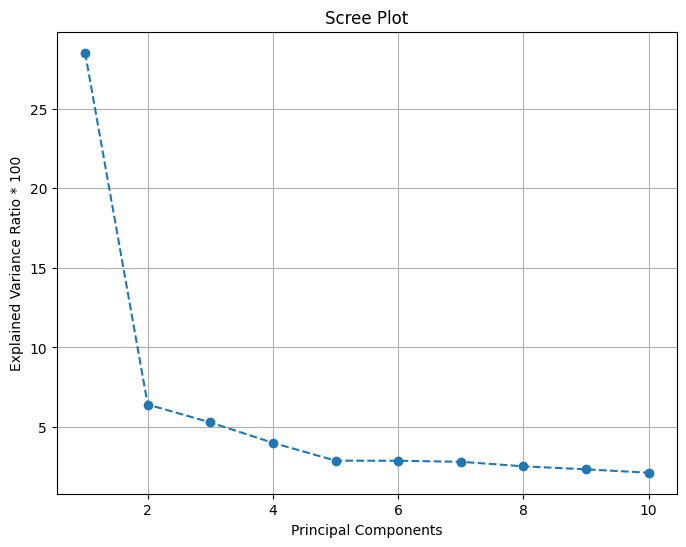

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,11), pca.explained_variance_ratio_*100, marker='o', linestyle='--')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio * 100')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [16]:
# industry_map = (nifty50_df[['Symbol', 'Sector[18]']].drop_duplicates('Symbol').set_index('Symbol')['Sector[18]']) # 2 years
industry_map = (nifty50_df[['Symbol', 'Sector[15]']].drop_duplicates('Symbol').set_index('Symbol')['Sector[15]']) # 1 year

In [17]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_df['Industry'] = pc1_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc1_sorted.head(10))
display(pc1_sorted.tail(10))

,Ticker,Weight,Industry
36,SBIN.NS,18.723401,Financial Services
14,GRASIM.NS,18.225647,Construction Materials
27,LT.NS,17.801977,Construction
40,TATASTEEL.NS,17.468644,Metals & Mining
6,BAJAJFINSV.NS,17.435269,Financial Services
34,RELIANCE.NS,17.229511,"Oil, Gas & Consumable Fuels"
7,BAJFINANCE.NS,17.196079,Financial Services
25,JSWSTEEL.NS,17.086564,Metals & Mining
1,ADANIPORTS.NS,16.955241,Services
45,ULTRACEMCO.NS,16.850829,Construction Materials


,Ticker,Weight,Industry
15,HCLTECH.NS,12.601813,Information Technology
5,BAJAJ-AUTO.NS,12.563360,Automobile and Auto Components
32,ONGC.NS,12.140115,"Oil, Gas & Consumable Fuels"
38,SUNPHARMA.NS,11.704885,Healthcare
3,ASIANPAINT.NS,11.419047,Consumer Durables
2,APOLLOHOSP.NS,11.165565,Healthcare
30,NESTLEIND.NS,9.907609,Fast Moving Consumer Goods
20,HINDUNILVR.NS,9.741751,Fast Moving Consumer Goods
12,DRREDDY.NS,8.585601,Healthcare
10,CIPLA.NS,5.716756,Healthcare


In [18]:
pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_df['Industry'] = pc2_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc2_sorted.head(10))
display(pc2_sorted.tail(10))

,Ticker,Weight,Industry
23,INFY.NS,32.504894,Information Technology
41,TCS.NS,32.307345,Information Technology
15,HCLTECH.NS,29.200095,Information Technology
42,TECHM.NS,26.860537,Information Technology
46,WIPRO.NS,24.531705,Information Technology
20,HINDUNILVR.NS,23.868659,Fast Moving Consumer Goods
30,NESTLEIND.NS,19.986976,Fast Moving Consumer Goods
3,ASIANPAINT.NS,17.625283,Consumer Durables
39,TATACONSUM.NS,15.234001,Fast Moving Consumer Goods
12,DRREDDY.NS,11.685332,Healthcare


,Ticker,Weight,Industry
37,SHRIRAMFIN.NS,-12.259669,Financial Services
0,ADANIENT.NS,-12.275499,Metals & Mining
1,ADANIPORTS.NS,-13.836446,Services
40,TATASTEEL.NS,-15.110116,Metals & Mining
36,SBIN.NS,-18.026183,Financial Services
33,POWERGRID.NS,-18.388020,Power
8,BEL.NS,-18.388318,Capital Goods
32,ONGC.NS,-22.106703,"Oil, Gas & Consumable Fuels"
11,COALINDIA.NS,-22.478078,"Oil, Gas & Consumable Fuels"
31,NTPC.NS,-23.748154,Power


In [19]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_df['Industry'] = pc3_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc3_sorted.head(10))
display(pc3_sorted.tail(10))

,Ticker,Weight,Industry
15,HCLTECH.NS,27.168887,Information Technology
42,TECHM.NS,26.414083,Information Technology
23,INFY.NS,24.697444,Information Technology
46,WIPRO.NS,23.665738,Information Technology
41,TCS.NS,23.124679,Information Technology
32,ONGC.NS,22.374353,"Oil, Gas & Consumable Fuels"
19,HINDALCO.NS,22.119335,Metals & Mining
40,TATASTEEL.NS,21.283612,Metals & Mining
11,COALINDIA.NS,19.175621,"Oil, Gas & Consumable Fuels"
25,JSWSTEEL.NS,17.517010,Metals & Mining


,Ticker,Weight,Industry
7,BAJFINANCE.NS,-12.472974,Financial Services
26,KOTAKBANK.NS,-12.537691,Financial Services
28,M&M.NS,-13.711096,Automobile and Auto Components
18,HEROMOTOCO.NS,-15.968527,Automobile and Auto Components
5,BAJAJ-AUTO.NS,-17.658793,Automobile and Auto Components
13,EICHERMOT.NS,-17.700045,Automobile and Auto Components
30,NESTLEIND.NS,-19.161395,Fast Moving Consumer Goods
3,ASIANPAINT.NS,-19.237569,Consumer Durables
29,MARUTI.NS,-22.586323,Automobile and Auto Components
20,HINDUNILVR.NS,-25.497466,Fast Moving Consumer Goods


In [20]:
pc4_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[3] * 100
})

pc4_df['Industry'] = pc4_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc4_sorted = pc4_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc4_sorted.head(10))
display(pc4_sorted.tail(10))

,Ticker,Weight,Industry
10,CIPLA.NS,33.890518,Healthcare
12,DRREDDY.NS,31.349556,Healthcare
38,SUNPHARMA.NS,29.175456,Healthcare
30,NESTLEIND.NS,18.971447,Fast Moving Consumer Goods
5,BAJAJ-AUTO.NS,17.822866,Automobile and Auto Components
33,POWERGRID.NS,16.079571,Power
18,HEROMOTOCO.NS,15.504827,Automobile and Auto Components
11,COALINDIA.NS,14.233467,"Oil, Gas & Consumable Fuels"
44,TRENT.NS,12.838274,Consumer Services
39,TATACONSUM.NS,12.363777,Fast Moving Consumer Goods


,Ticker,Weight,Industry
41,TCS.NS,-10.567445,Information Technology
22,INDUSINDBK.NS,-14.619327,Financial Services
23,INFY.NS,-15.375614,Information Technology
36,SBIN.NS,-15.727868,Financial Services
26,KOTAKBANK.NS,-18.878524,Financial Services
6,BAJAJFINSV.NS,-21.620792,Financial Services
4,AXISBANK.NS,-21.965024,Financial Services
7,BAJFINANCE.NS,-23.313497,Financial Services
16,HDFCBANK.NS,-24.769464,Financial Services
21,ICICIBANK.NS,-26.156495,Financial Services


### Performance Measurement

In [ ]:
# ==============================================================================
# 1. CORE MATH & PORTFOLIO SIMULATION ENGINES
# ==============================================================================
def extract_strategy_weights(pca_model, columns, pc_index, strategy_type='auto'):
    """Extracts and normalizes weights based on the chosen strategy."""
    raw_weights = pca_model.components_[pc_index]
    
    # Auto-detect strategy: PC1 is usually Long-Only, everything else is Long/Short
    if strategy_type == 'auto':
        strategy_type = 'long_only' if pc_index == 0 else 'long_short'
        
    if strategy_type == 'long_only':
        # Fix sign direction for PC1
        if np.sum(raw_weights) < 0:
            raw_weights = -raw_weights
        long_weights = np.maximum(0, raw_weights)
        return pd.Series(long_weights / np.sum(long_weights), index=columns), 'Long-Only'
        
    elif strategy_type == 'long_short':
        # Normalize Longs to +1.0 and Shorts to -1.0 (Dollar Neutral)
        longs = np.maximum(0, raw_weights)
        shorts = np.minimum(0, raw_weights)
        norm_longs = longs / np.sum(longs) if np.sum(longs) > 0 else longs
        norm_shorts = shorts / abs(np.sum(shorts)) if np.sum(shorts) < 0 else shorts
        return pd.Series(norm_longs + norm_shorts, index=columns), 'Long/Short (Market Neutral)'

def simulate_portfolio(price_data, weights, initial_capital, strategy_name):
    """Simulates the portfolio equity curve based on strategy type."""
    initial_prices = price_data.iloc[0]
    shares = (initial_capital * weights) / initial_prices
    
    if strategy_name == 'Long-Only':
        # Portfolio value is just the current value of the shares held
        return price_data.dot(shares)
    else:
        # Long/Short Portfolio: Initial Capital is margin. 
        # PnL = (Current Prices * Shares). Note: Shorts are negative shares, so dropping prices = profit.
        return initial_capital + price_data.dot(shares)

def align_benchmark(benchmark_data, initial_capital):
    """Normalizes the benchmark to start at the exact same capital as the portfolio."""
    if isinstance(benchmark_data, pd.DataFrame):
        benchmark_data = benchmark_data.iloc[:, 0]
    return (benchmark_data / benchmark_data.iloc[0]) * initial_capital

# ==============================================================================
# 2. INSTITUTIONAL METRICS ENGINE
# ==============================================================================
def calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr):
    df = pd.concat([port_val, bench_val], axis=1).dropna()
    df.columns = ['Portfolio', 'Benchmark']
    
    returns = df.pct_change().dropna()
    p_ret, b_ret = returns['Portfolio'], returns['Benchmark']
    
    # CAGR
    ann_p_ret = (df['Portfolio'].iloc[-1] / df['Portfolio'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    ann_b_ret = (df['Benchmark'].iloc[-1] / df['Benchmark'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    
    # Volatility
    ann_p_vol = p_ret.std() * np.sqrt(periods_per_yr)
    ann_b_vol = b_ret.std() * np.sqrt(periods_per_yr)
    
    # Sharpe
    p_sharpe = (ann_p_ret - rf_rate) / ann_p_vol
    b_sharpe = (ann_b_ret - rf_rate) / ann_b_vol
    
    # Sortino
    p_down_dev = np.sqrt(np.mean(np.where(p_ret < 0, p_ret**2, 0))) * np.sqrt(periods_per_yr)
    p_sortino = (ann_p_ret - rf_rate) / p_down_dev if p_down_dev > 0 else np.nan
    b_down_dev = np.sqrt(np.mean(np.where(b_ret < 0, b_ret**2, 0))) * np.sqrt(periods_per_yr)
    b_sortino = (ann_b_ret - rf_rate) / b_down_dev if b_down_dev > 0 else np.nan
    
    # Drawdowns
    p_dd = (df['Portfolio'] - df['Portfolio'].cummax()) / df['Portfolio'].cummax()
    b_dd = (df['Benchmark'] - df['Benchmark'].cummax()) / df['Benchmark'].cummax()
    
    # Beta & Alpha
    cov = np.cov(p_ret, b_ret)
    beta = cov[0, 1] / cov[1, 1]
    alpha = ann_p_ret - (rf_rate + beta * (ann_b_ret - rf_rate))
    
    # Calmar
    p_calmar = ann_p_ret / abs(p_dd.min())
    b_calmar = ann_b_ret / abs(b_dd.min())
    
    metrics = pd.DataFrame({
        'Portfolio': [f"{ann_p_ret*100:.2f}%", f"{ann_p_vol*100:.2f}%", f"{p_sharpe:.2f}", f"{p_sortino:.2f}", f"{p_dd.min()*100:.2f}%", f"{p_calmar:.2f}", f"{beta:.2f}", f"{alpha*100:.2f}%"],
        'Benchmark': [f"{ann_b_ret*100:.2f}%", f"{ann_b_vol*100:.2f}%", f"{b_sharpe:.2f}", f"{b_sortino:.2f}", f"{b_dd.min()*100:.2f}%", f"{b_calmar:.2f}", "1.00", "0.00%"]
    }, index=['Return (CAGR)', 'Volatility', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Calmar Ratio', 'Beta', "Jensen's Alpha"])
    
    return metrics, p_dd, b_dd, p_ret, b_ret

# ==============================================================================
# 3. MASTER WRAPPER & PLOTTING DASHBOARD
# ==============================================================================
def evaluate_pc_strategy(pca_model, pc_index, price_data, benchmark_data, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52):
    """
    The Ultimate Master Function. Put in a PC index, get out the full institutional dashboard.
    """
    # 1. Build Portfolio
    weights, strat_name = extract_strategy_weights(pca_model, price_data.columns, pc_index, strategy)
    port_val = simulate_portfolio(price_data, weights, initial_capital, strat_name)
    bench_val = align_benchmark(benchmark_data, initial_capital)
    
    # 2. Get Metrics
    metrics_df, p_dd, b_dd, p_ret, b_ret = calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr)
    
    # 3. Print Results
    actual_pc = pc_index + 1
    print("\n" + "="*65)
    print(f" STRATEGY REPORT: Principal Component {actual_pc} [{strat_name}]")
    print("="*65)
    display(metrics_df)
    
    # 4. Render Dashboard
    fig = plt.figure(figsize=(14, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 1, 1], hspace=0.3)
    
    # Chart 1: Equity Curve
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(port_val.index, (port_val/initial_capital)*100, label=f'PC{actual_pc} Portfolio', color='#1f77b4', linewidth=2.5)
    ax1.plot(bench_val.index, (bench_val/initial_capital)*100, label='Benchmark', color='#4a4a4a', linewidth=1.5, alpha=0.8)
    ax1.set_title(f'Equity Curve (Normalized to 100 Base)', fontsize=14, fontweight='bold', loc='left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')
    
    # Chart 2: Drawdowns
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(p_dd.index, p_dd * 100, 0, color='#d62728', alpha=0.3, label='Portfolio Drawdown')
    ax2.plot(b_dd.index, b_dd * 100, color='black', linewidth=1.2, alpha=0.7, label='Benchmark Drawdown')
    ax2.set_title('Underwater Plot (Capital Drawdowns %)', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right')
    
    # Chart 3: Rolling Beta
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    rolling_window = max(int(periods_per_yr / 2), 1) # 6-month rolling window
    rolling_beta = p_ret.rolling(window=rolling_window).cov(b_ret) / b_ret.rolling(window=rolling_window).var()
    ax3.plot(rolling_beta.index, rolling_beta, color='#2ca02c', linewidth=2, label=f'Rolling {rolling_window}-Period Beta')
    ax3.axhline(1.0 if strat_name == 'Long-Only' else 0.0, color='black', linestyle='--', alpha=0.5, label='Target Beta')
    ax3.set_title(f'Systemic Risk (Rolling {rolling_window}-Period Beta)', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, linestyle='--', alpha=0.5)
    ax3.legend(loc='lower left')
    
    plt.show()




 STRATEGY REPORT: Principal Component 1 [Long-Only]


,Portfolio,Benchmark
Return (CAGR),9.97%,3.82%
Volatility,13.79%,14.03%
Sharpe Ratio,0.29,-0.16
Sortino Ratio,0.41,-0.22
Max Drawdown,-11.96%,-15.18%
Calmar Ratio,0.83,0.25
Beta,0.95,1.00
Jensen's Alpha,6.04%,0.00%


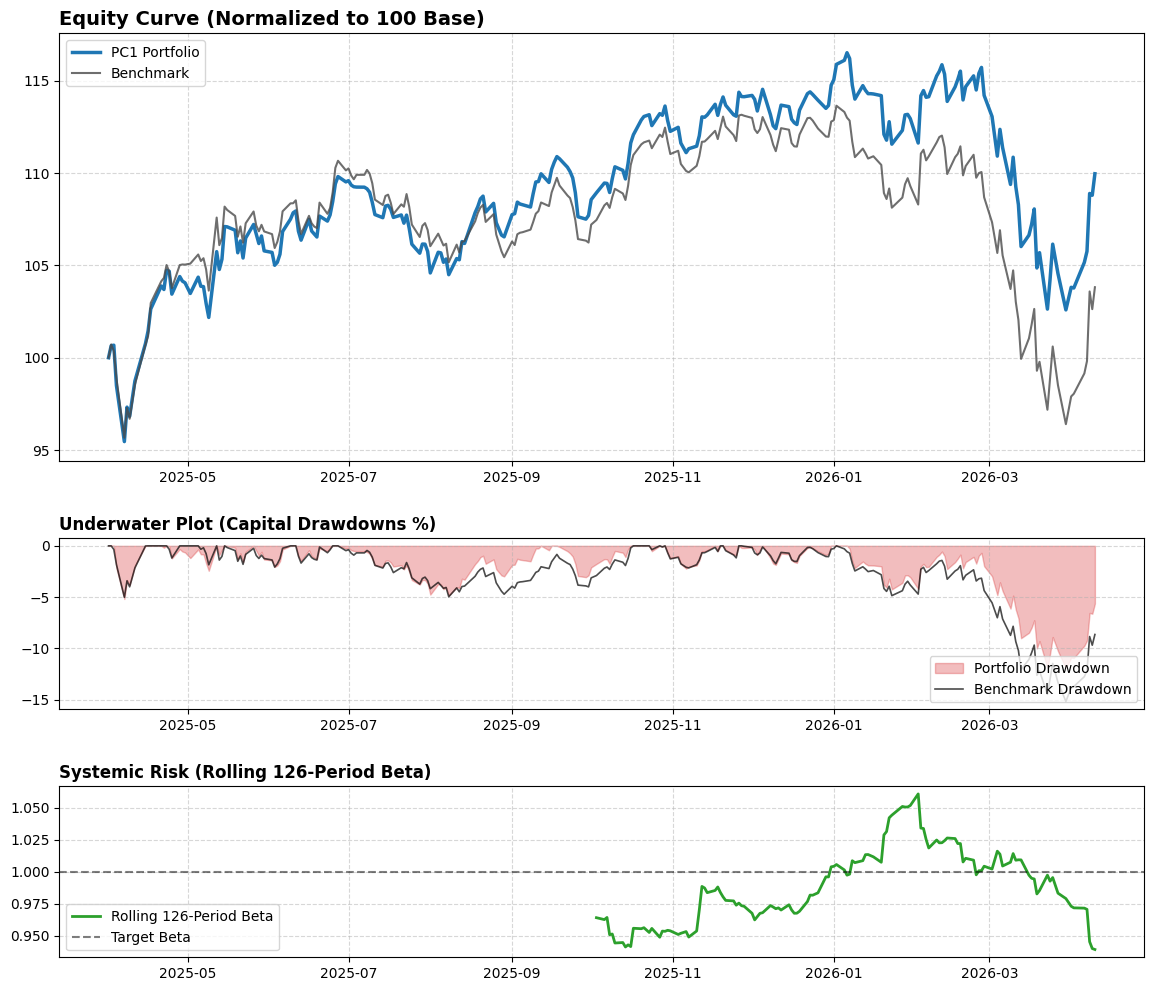

In [33]:
# Test PC1
evaluate_pc_strategy(pca_model=pca, pc_index=0, price_data=close_test_prices, benchmark_data=benchmark, periods_per_yr=252)


 STRATEGY REPORT: Principal Component 2 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-16.64%,3.82%
Volatility,14.50%,14.03%
Sharpe Ratio,-1.56,-0.16
Sortino Ratio,-2.05,-0.22
Max Drawdown,-19.38%,-15.18%
Calmar Ratio,-0.86,0.25
Beta,-0.12,1.00
Jensen's Alpha,-22.91%,0.00%


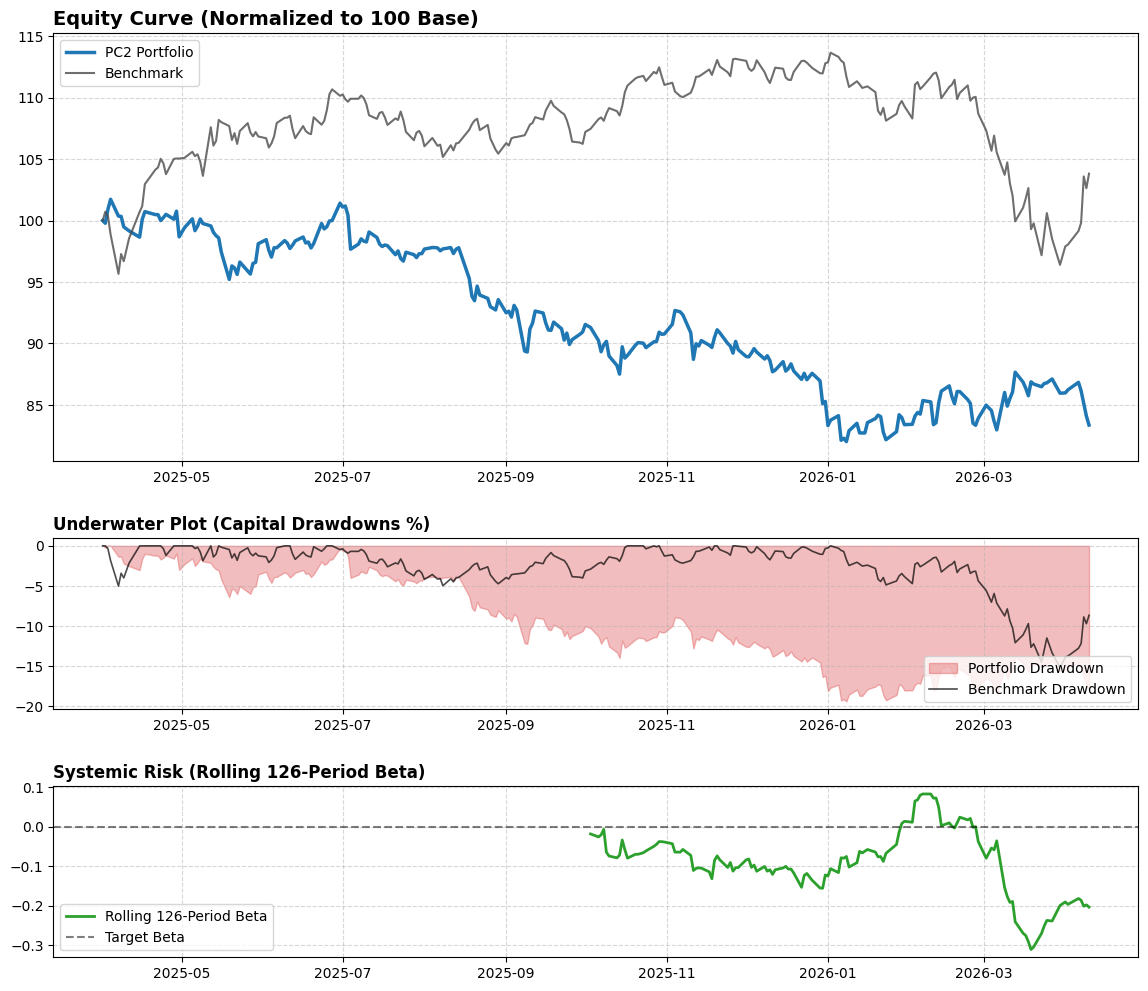

In [34]:
# Test PC2
evaluate_pc_strategy(pca_model=pca, pc_index=1, price_data=close_test_prices, benchmark_data=benchmark, periods_per_yr=252)


 STRATEGY REPORT: Principal Component 3 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-10.16%,3.82%
Volatility,14.11%,14.03%
Sharpe Ratio,-1.15,-0.16
Sortino Ratio,-1.61,-0.22
Max Drawdown,-22.82%,-15.18%
Calmar Ratio,-0.45,0.25
Beta,-0.10,1.00
Jensen's Alpha,-16.38%,0.00%


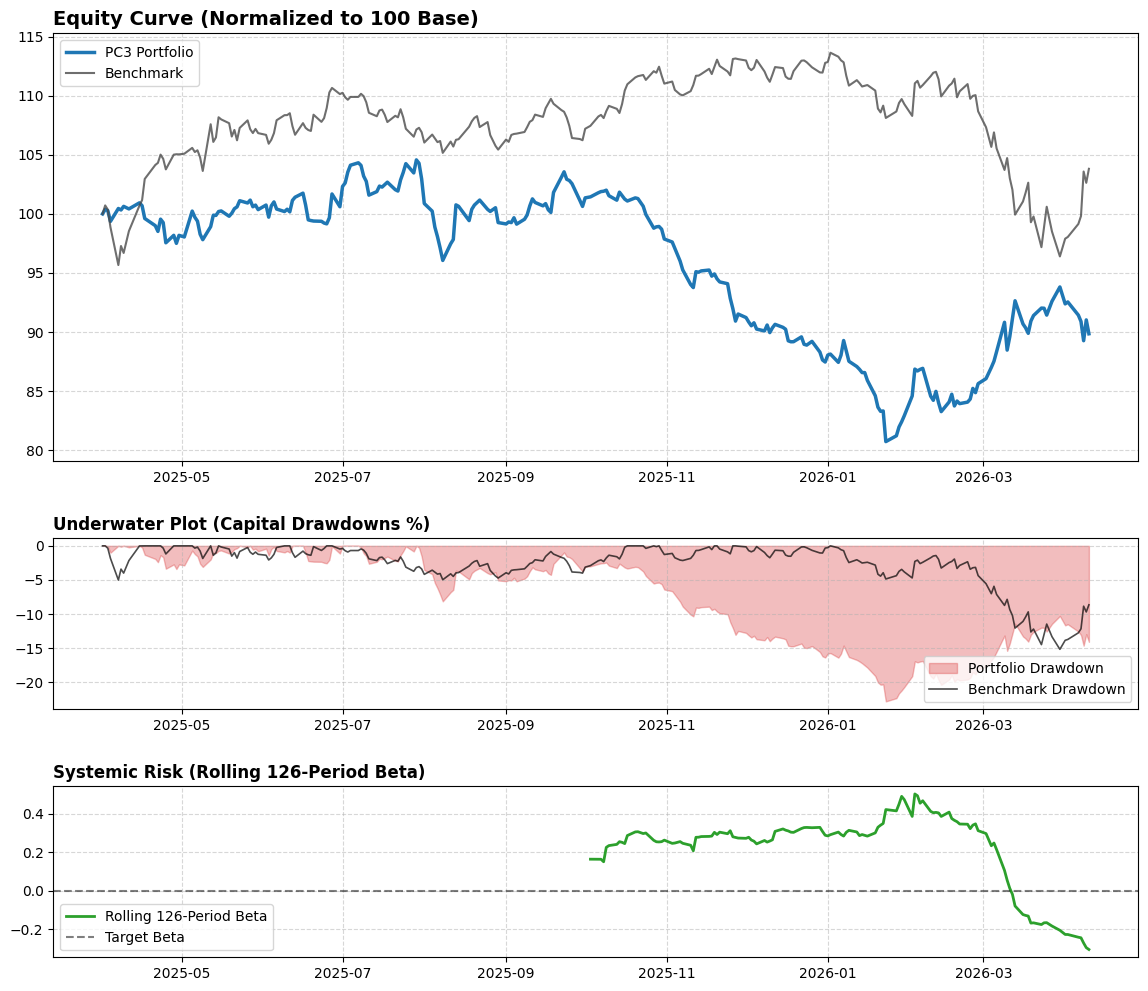

In [35]:
# Test PC3
evaluate_pc_strategy(pca_model=pca, pc_index=2, price_data=close_test_prices, benchmark_data=benchmark, periods_per_yr=252)


 STRATEGY REPORT: Principal Component 4 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),10.17%,3.82%
Volatility,16.26%,14.03%
Sharpe Ratio,0.26,-0.16
Sortino Ratio,0.37,-0.22
Max Drawdown,-12.17%,-15.18%
Calmar Ratio,0.84,0.25
Beta,-0.17,1.00
Jensen's Alpha,3.80%,0.00%


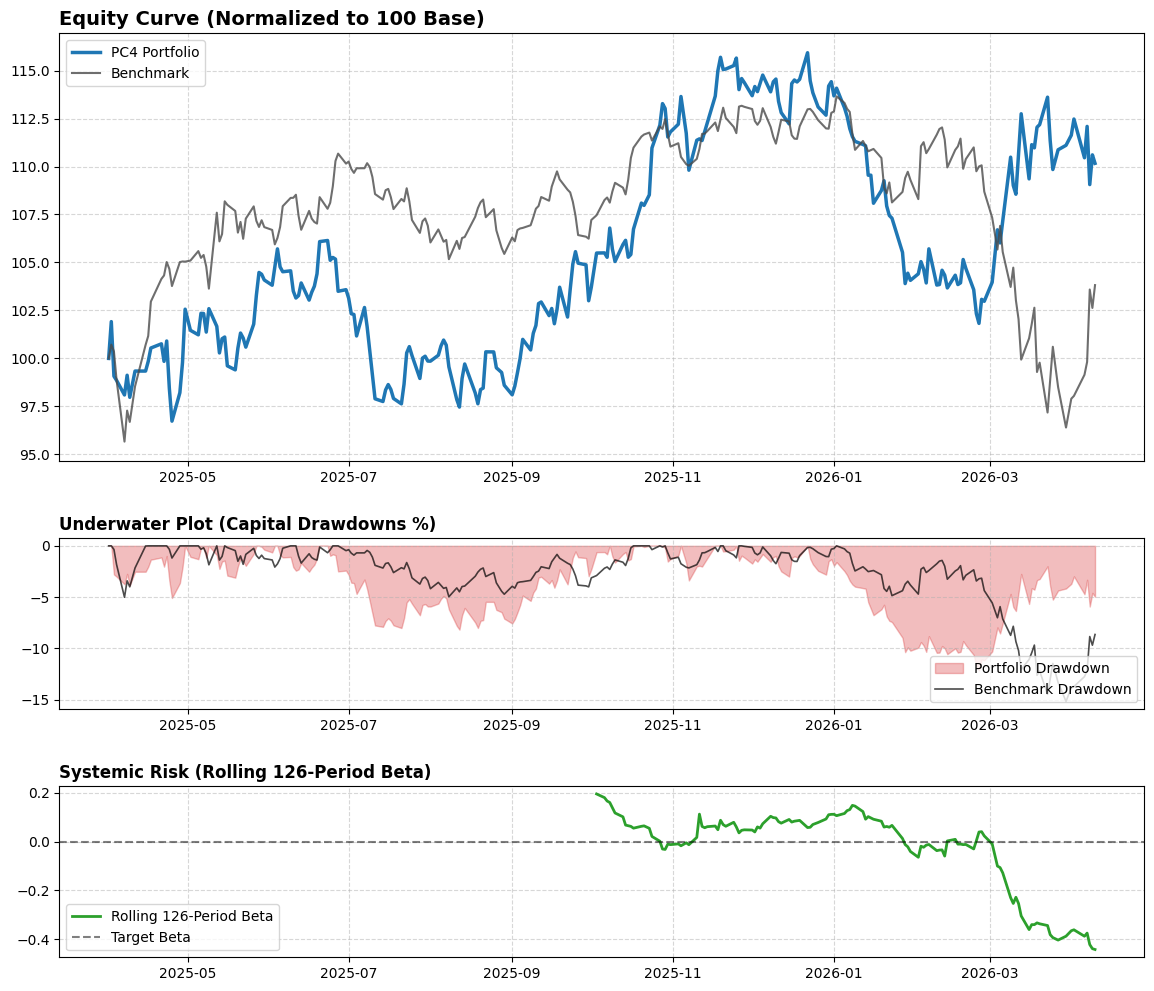

In [36]:
evaluate_pc_strategy(pca_model=pca, pc_index=3, price_data=close_test_prices, benchmark_data=benchmark, periods_per_yr=252)


 MULTI-FACTOR PORTFOLIO: PC2 + PC3 + PC4 (Equal Weighting)


,Portfolio,Benchmark
Return (CAGR),-5.54%,3.82%
Volatility,9.84%,14.03%
Sharpe Ratio,-1.17,-0.16
Sortino Ratio,-1.66,-0.22
Max Drawdown,-12.07%,-15.18%
Calmar Ratio,-0.46,0.25
Beta,-0.14,1.00
Jensen's Alpha,-11.84%,0.00%


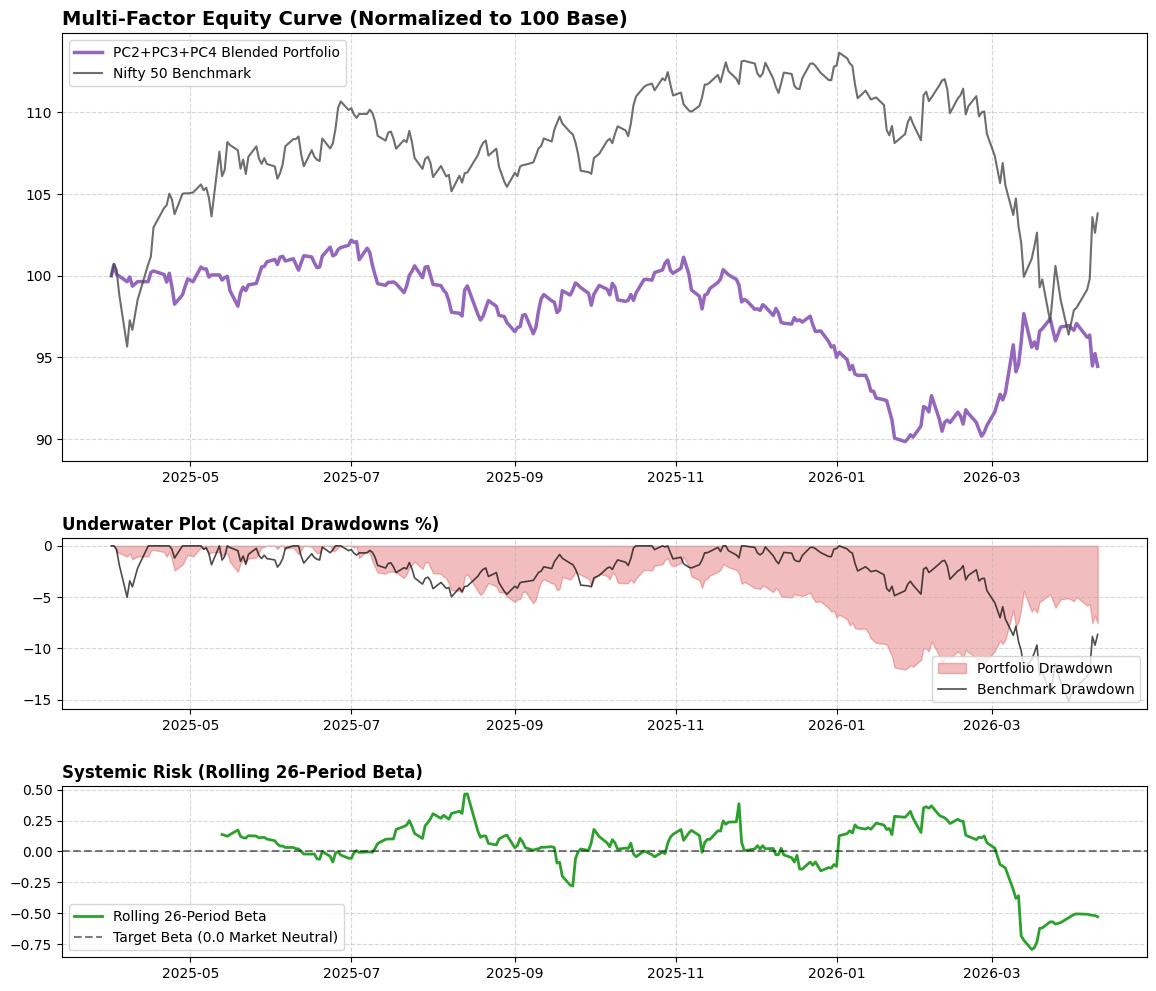

In [ ]:
# ==============================================================================
# 1. MULTI-FACTOR WEIGHT GENERATOR
# ==============================================================================
def get_combined_multi_pc_weights(pca_model, columns, pc_indices, allocations):
    """
    Combines multiple Principal Components into a single weighted portfolio.
    Assumes all provided components are traded as Market-Neutral Long/Short.
    """
    # Start with a blank slate of 0.0 weights for all stocks
    combined_weights = pd.Series(0.0, index=columns)
    
    for pc_idx, alloc in zip(pc_indices, allocations):
        # Extract raw weights for this component
        raw_weights = pca_model.components_[pc_idx]
        
        # Normalize as Long/Short (+1.0 Longs, -1.0 Shorts)
        longs = np.maximum(0, raw_weights)
        shorts = np.minimum(0, raw_weights)
        
        norm_longs = longs / np.sum(longs) if np.sum(longs) > 0 else longs
        norm_shorts = shorts / abs(np.sum(shorts)) if np.sum(shorts) < 0 else shorts
        
        # This component's final normalized weights
        pc_weights = pd.Series(norm_longs + norm_shorts, index=columns)
        
        # Apply the allocation multiplier and add to the master portfolio
        combined_weights += (pc_weights * alloc)
        
    return combined_weights

# ==============================================================================
# 2. EXECUTION & DASHBOARD 
# ==============================================================================

# We want PC2 (Index 1), PC3 (Index 2), and PC4 (Index 3)
indices_to_combine = [1, 2, 3] 

# Equal weightage: 33.33% allocated to each component
allocations = [1/3, 1/3, 1/3]

# Generate the Master Blended Weights
master_weights = get_combined_multi_pc_weights(pca, close_test_prices.columns, indices_to_combine, allocations)

# Since PC2, 3, and 4 are all Market-Neutral spreads, the combined portfolio is also Long/Short
combined_port_val = simulate_portfolio(
    price_data=close_test_prices, 
    weights=master_weights, 
    initial_capital=100000, 
    strategy_name='Long/Short'
)
bench_val = align_benchmark(benchmark, initial_capital=100000)

# Calculate Institutional Metrics (Using 52 for Weekly data, change to 252 if using Daily)
metrics_df_combo, p_dd, b_dd, p_ret, b_ret = calculate_metrics(
    port_val=combined_port_val, 
    bench_val=bench_val, 
    rf_rate=0.06, 
    periods_per_yr=252
)

# --- Print Results ---
print("\n" + "="*70)
print(" MULTI-FACTOR PORTFOLIO: PC2 + PC3 + PC4 (Equal Weighting)")
print("="*70)
display(metrics_df_combo)

# --- Render Custom Dashboard ---
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 1, 1], hspace=0.3)

# Chart 1: Equity Curve
ax1 = fig.add_subplot(gs[0])
ax1.plot(combined_port_val.index, (combined_port_val/100000)*100, label='PC2+PC3+PC4 Blended Portfolio', color='#9467bd', linewidth=2.5)
ax1.plot(bench_val.index, (bench_val/100000)*100, label='Nifty 50 Benchmark', color='#4a4a4a', linewidth=1.5, alpha=0.8)
ax1.set_title('Multi-Factor Equity Curve (Normalized to 100 Base)', fontsize=14, fontweight='bold', loc='left')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

# Chart 2: Drawdowns
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.fill_between(p_dd.index, p_dd * 100, 0, color='#d62728', alpha=0.3, label='Portfolio Drawdown')
ax2.plot(b_dd.index, b_dd * 100, color='black', linewidth=1.2, alpha=0.7, label='Benchmark Drawdown')
ax2.set_title('Underwater Plot (Capital Drawdowns %)', fontsize=12, fontweight='bold', loc='left')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right')

# Chart 3: Rolling Beta
ax3 = fig.add_subplot(gs[2], sharex=ax1)
rolling_window = 26 # 6-month rolling window for weekly data
rolling_beta = p_ret.rolling(window=rolling_window).cov(b_ret) / b_ret.rolling(window=rolling_window).var()
ax3.plot(rolling_beta.index, rolling_beta, color='#2ca02c', linewidth=2, label=f'Rolling {rolling_window}-Period Beta')
ax3.axhline(0.0, color='black', linestyle='--', alpha=0.5, label='Target Beta (0.0 Market Neutral)')
ax3.set_title(f'Systemic Risk (Rolling {rolling_window}-Period Beta)', fontsize=12, fontweight='bold', loc='left')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='lower left')

plt.show()